# Term Project V2 - ทำนายราคาอสังหาริมทรัพย์ แยกตาม property_type (แบบแยกทีละกลุ่ม ไม่ใช้ loop)

ไฟล์นี้ทำต่อจาก `TermprojectV2_Others.ipynb` แต่ **เขียนแยกทีละกลุ่ม** ไม่มี `for` วนทั้งตาราง

- ทุกขั้นตอน (เตรียมข้อมูล → train → tune → ทำนาย) ของแต่ละกลุ่มอยู่ในหมวดของตัวเอง
- ตัวแปรของแต่ละกลุ่มแยกกันชัดเจน เช่น `X_train_condo`, `model_house`, `new_condo`
- ปิดท้ายด้วยหมวด "รวมผล" ที่เอาผลของทั้ง 5 กลุ่มมาวางเทียบกัน

กลุ่มที่ต้องแยก: **Condo, Detached House, Townhouse, Apartment, Land**

ข้อมูล: `ddproperty_2022-04-19.csv`

## 1) Import library

In [407]:
import numpy as np
import pandas as pd
from scipy import stats
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

RANDOM_STATE = 42
TEST_SIZE = 0.3
PRICE_QUANTILE = 0.99

## 2) Read File

In [408]:
df = pd.read_csv('ddproperty_2022-04-19.csv', low_memory=False)
print('shape      :', df.shape)
print('duplicated :', df.duplicated().sum())

z = np.abs(stats.zscore(df['price']))
print('outliers |z| > 3 :', len(df[z > 3]))

shape      : (220557, 69)
duplicated : 0
outliers |z| > 3 : 21


## 3) ลบคอลัมน์ที่เป็น null ทั้งหมด

ต้องตัดคอลัมน์ที่ไม่มีข้อมูลเลยออกก่อน ไม่อย่างนั้น `dropna()` จะลบทุกแถวทิ้งหมด

In [409]:
all_null_cols = [c for c in df.columns if df[c].isnull().all()]
print('all-null columns:', len(all_null_cols))

df = df.drop(columns=all_null_cols)
print('shape after drop:', df.shape)

all-null columns: 21
shape after drop: (220557, 48)


## 4) แยกเป็น 5 กลุ่ม (เขียนแยกทีละบรรทัด ไม่ใช้ `groupby` วน)

ถ้าใช้ `df.dropna()` ทั้งตารางจะเหลือแค่ 601 แถว เพราะ `land_space` null 61% และ `living_space` null 14.5%

วิธีแก้คือ **แยกกลุ่มก่อน แล้วลบ null เฉพาะคอลัมน์ที่แต่ละกลุ่มต้องใช้**

In [410]:
df_condo = df[df['property_type'] == 'Condo'].copy()
df_house = df[df['property_type'] == 'Detached House'].copy()
df_townhouse = df[df['property_type'] == 'Townhouse'].copy()
df_apartment = df[df['property_type'] == 'Apartment'].copy()
df_land = df[df['property_type'] == 'Land'].copy()

print('df_condo    ', df_condo.shape)
print('df_house    ', df_house.shape)
print('df_townhouse', df_townhouse.shape)
print('df_apartment', df_apartment.shape)
print('df_land     ', df_land.shape)

df_condo     (129129, 48)
df_house     (42721, 48)
df_townhouse (18697, 48)
df_apartment (4553, 48)
df_land      (25457, 48)


## 5) ลบแถว null ทีละกลุ่ม

แต่ละกลุ่มต้องการคอลัมน์คนละชุดกัน เพราะคอลัมน์ที่มีข้อมูลครบต่างกัน เช่น `Condo` ไม่มี `land_space` เลย

In [411]:
df_condo = df_condo.dropna(subset=['price', 'city', 'state', 'living_space'])
df_house = df_house.dropna(subset=['price', 'city', 'state', 'living_space'])
df_townhouse = df_townhouse.dropna(subset=['price', 'city', 'state', 'living_space'])
df_apartment = df_apartment.dropna(subset=['price', 'city', 'state', 'living_space'])
df_land = df_land.dropna(subset=['price', 'city', 'state', 'land_space'])

print('df_condo    ', len(df_condo), 'rows')
print('df_house    ', len(df_house), 'rows')
print('df_townhouse', len(df_townhouse), 'rows')
print('df_apartment', len(df_apartment), 'rows')
print('df_land     ', len(df_land), 'rows')

print('TOTAL', len(df_condo) + len(df_house) + len(df_townhouse)
      + len(df_apartment) + len(df_land), 'rows')

df_condo     128846 rows
df_house     39119 rows
df_townhouse 16333 rows
df_apartment 4172 rows
df_land      25446 rows
TOTAL 213916 rows


## 6) คอลัมน์ที่เลือกใช้ของแต่ละกลุ่ม

เลือกเฉพาะคอลัมน์ที่ **coverage สูงพอ** ไม่งั้น `dropna()` จะทิ้งข้อมูลเกือบหมด

| กลุ่ม | built_year | floor_level | tenure | furnished | land_space |
|---|---|---|---|---|---|
| Condo | 81.1% | 43.4% | 77.4% | 53.0% | 0% |
| Detached House | 4.3% | 40.5% | 26.5% | 42.4% | 93.1% |
| Townhouse | 5.8% | 74.2% | 33.8% | 33.1% | 91.4% |
| Apartment | 2.2% | 60.3% | 27.9% | 53.4% | 71.1% |
| Land | 0.3% | 4.6% | 29.6% | 0.1% | 100.0% |

- `land_space` ของ Condo = **0%** (คอนโดไม่มีขนาดที่ดิน) จึงต้องตัดออก
- `built_year` ของบ้าน/ทาวน์เฮาส์/อพาร์ตเมนต์ < 6% ตัดออกเช่นกัน
- `Land` เหลือแค่ 3 คอลัมน์ (`land_space`, `city`, `state`) เพราะ `living_space` = **0%** และคอลัมน์อื่น coverage ต่ำกว่า 5%

## 7) ฟังก์ชันช่วยเตรียมข้อมูลและประเมินผล

ใช้ฟังก์ชันเดียวกันทั้ง 5 กลุ่ม แต่ **เรียกแยกทีละกลุ่ม** ในหมวดของแต่ละกลุ่ม

In [412]:
def prepare(data, features, quantile=PRICE_QUANTILE):
    """ลบแถว null ของ feature ที่เลือก แล้วกรองราคาที่เป็น outlier"""
    data = data.dropna(subset=features).copy()

    lo_price = 100_000
    hi_price = data['price'].quantile(quantile)
    data = data[(data['price'] >= lo_price) & (data['price'] <= hi_price)]

    return data, data[features].copy(), data['price']


def metrics(model, X_test, y_test):
    """คำนวณ MAE / RMSE / R2 ของโมเดล"""
    y_pred = model.predict(X_test)
    return {
        'MAE': mean_absolute_error(y_test, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
        'R2': r2_score(y_test, y_pred),
    }


def report(model, X_test, y_test, model_name):
    """พิมพ์รายละเอียดของโมเดล แล้วคืนค่า metrics"""
    m = metrics(model, X_test, y_test)
    print(f'===== {model_name} =====')
    print(f'depth  = {model.get_depth()}')
    print(f'leaves = {model.get_n_leaves():,}')
    print(f"MAE  : {m['MAE']:,.2f}")
    print(f"RMSE : {m['RMSE']:,.2f}")
    print(f"R²   : {m['R2']:.4f}")
    print()
    return m


def encode_column(values, encoder, fallback):
    """แปลงค่าข้อความเป็นตัวเลข ถ้าไม่เคยเจอให้ใช้ค่าที่พบบ่อยสุด"""
    codes = pd.Categorical(values, categories=encoder.classes_).codes
    return pd.Series(np.where(codes == -1, fallback, codes), index=values.index)

---

# 8) Condo

กลุ่มนี้มีข้อมูลเยอะที่สุด (~59%) และ **ไม่มี `land_space` เลย** จึงใช้ 8 คอลัมน์

ราคาคอนโดผูกกับ `living_space` + ปีที่สร้าง + จังหวัด/กรุงเทพฯ มากที่สุด

### 8.1 Condo — เตรียมข้อมูลและแบ่ง train/test

rows=39020  train=27314  test=11706
price kept: 100,000 - 33,000,000


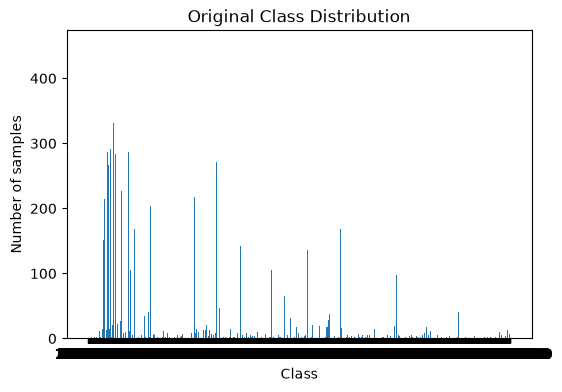

In [413]:
FEATURES_CONDO = ['living_space', 'bedroom_number', 'bathroom_number',
                  'built_year', 'floor_level', 'tenure', 'city', 'state']

condo, X_condo, y_condo = prepare(df_condo, FEATURES_CONDO)

# คอลัมน์ข้อความของ Condo: floor_level, tenure, city, state
floor_enc_condo = LabelEncoder().fit(X_condo['floor_level'])
tenure_enc_condo = LabelEncoder().fit(X_condo['tenure'])
city_enc_condo = LabelEncoder().fit(X_condo['city'])
state_enc_condo = LabelEncoder().fit(X_condo['state'])


X_condo['floor_level'] = floor_enc_condo.transform(X_condo['floor_level'])
X_condo['tenure'] = tenure_enc_condo.transform(X_condo['tenure' ])
X_condo['city'] = city_enc_condo.transform(X_condo['city'])
X_condo['state'] = state_enc_condo.transform(X_condo['state'])


X_train_condo, X_test_condo, y_train_condo, y_test_condo = train_test_split(
    X_condo, y_condo, test_size=TEST_SIZE, random_state=RANDOM_STATE)

print(f'rows={len(condo)}  train={len(X_train_condo)}  test={len(X_test_condo)}')
print(f'price kept: 100,000 - {condo["price"].quantile(PRICE_QUANTILE):,.0f}')

classDistribution = y_condo.value_counts().sort_index()
plt.figure(figsize=(6, 4))
plt.bar(classDistribution.index.astype(str), classDistribution.values)
plt.xlabel("Class")
plt.ylabel("Number of samples")
plt.title("Original Class Distribution")
plt.show()

### 8.2 Condo — DecisionTreeRegressor ค่า default

ค่า default ไม่จำกัดความลึก → ต้นไม้โตจนจำข้อมูลฝึกจน overfit

In [414]:
model_condo_default = DecisionTreeRegressor(random_state=RANDOM_STATE)
model_condo_default.fit(X_train_condo, y_train_condo)

res_condo_default = report(
    model_condo_default, X_test_condo, y_test_condo, 'DT default Condo')

===== DT default Condo =====
depth  = 31
leaves = 17,451
MAE  : 857,173.53
RMSE : 2,142,259.53
R²   : 0.8712



### 8.3 Condo — Tune `max_depth`

In [415]:
dt_condo_d3 = DecisionTreeRegressor(max_depth=3, random_state=RANDOM_STATE).fit(X_train_condo, y_train_condo)
dt_condo_d5 = DecisionTreeRegressor(max_depth=5, random_state=RANDOM_STATE).fit(X_train_condo, y_train_condo)
dt_condo_d8 = DecisionTreeRegressor(max_depth=8, random_state=RANDOM_STATE).fit(X_train_condo, y_train_condo)
dt_condo_d10 = DecisionTreeRegressor(max_depth=10, random_state=RANDOM_STATE).fit(X_train_condo, y_train_condo)
dt_condo_d12 = DecisionTreeRegressor(max_depth=12, random_state=RANDOM_STATE).fit(X_train_condo, y_train_condo)
dt_condo_d15 = DecisionTreeRegressor(max_depth=15, random_state=RANDOM_STATE).fit(X_train_condo, y_train_condo)
dt_condo_dnone = DecisionTreeRegressor(random_state=RANDOM_STATE).fit(X_train_condo, y_train_condo)

tuning_condo = pd.DataFrame([
    {'max_depth': 3, **metrics(dt_condo_d3, X_test_condo, y_test_condo)},
    {'max_depth': 5, **metrics(dt_condo_d5, X_test_condo, y_test_condo)},
    {'max_depth': 8, **metrics(dt_condo_d8, X_test_condo, y_test_condo)},
    {'max_depth': 10, **metrics(dt_condo_d10, X_test_condo, y_test_condo)},
    {'max_depth': 12, **metrics(dt_condo_d12, X_test_condo, y_test_condo)},
    {'max_depth': 15, **metrics(dt_condo_d15, X_test_condo, y_test_condo)},
    {'max_depth': 'None', **metrics(dt_condo_dnone, X_test_condo, y_test_condo)},
]).set_index('max_depth')

print('===== Condo =====')
print(tuning_condo.round(2).to_string())

===== Condo =====
                  MAE        RMSE    R2
max_depth                              
3          2041196.14  3427666.95  0.67
5          1741382.20  2998831.01  0.75
8          1439731.55  2543330.66  0.82
10         1250982.63  2332792.22  0.85
12         1096702.62  2212605.23  0.86
15          948466.80  2134123.14  0.87
None        857173.53  2142259.53  0.87


### 8.4 Condo — Final model (`max_depth = 15`)

เลือกค่าที่ **R² สูงสุด** ไม่ใช่ MAE ต่ำสุด เพราะ MAE ยังลดลงต่อเมื่อต้นไม้ลึกขึ้นเสมอ

In [416]:
BEST_DEPTH_CONDO = 15

model_condo = DecisionTreeRegressor(
    max_depth=BEST_DEPTH_CONDO, random_state=RANDOM_STATE)
model_condo.fit(X_train_condo, y_train_condo)

res_condo_tuned = report(
    model_condo, X_test_condo, y_test_condo, 'DT tuned Condo')

===== DT tuned Condo =====
depth  = 15
leaves = 5,722
MAE  : 948,466.80
RMSE : 2,134,123.14
R²   : 0.8722



### 8.5 Condo — Feature Importance

In [417]:
importance_condo = pd.Series(
    model_condo.feature_importances_, index=FEATURES_CONDO
).sort_values(ascending=False)

importance_condo.round(4)

living_space       0.7119
city               0.1048
built_year         0.0983
floor_level        0.0341
bathroom_number    0.0188
bedroom_number     0.0163
state              0.0155
tenure             0.0004
dtype: float64

### 8.6 Condo — ทดลองทำนายของใหม่

In [418]:
floor_mode_condo = np.bincount(floor_enc_condo.transform(condo['floor_level'])).argmax()
tenure_mode_condo = np.bincount(tenure_enc_condo.transform(condo['tenure'])).argmax()
city_mode_condo = np.bincount(city_enc_condo.transform(condo['city'])).argmax()
state_mode_condo = np.bincount(state_enc_condo.transform(condo['state'])).argmax()

new_condo = pd.DataFrame([
    {'living_space': 35, 'bedroom_number': 1, 'bathroom_number': 1,
     'built_year': 2018, 'floor_level': '12', 'tenure': 'Freehold',
     'city': 'Watthana', 'state': 'Bangkok'},
    {'living_space': 120, 'bedroom_number': 3, 'bathroom_number': 3,
     'built_year': 2021, 'floor_level': '25', 'tenure': 'Freehold',
     'city': 'Bang Rak', 'state': 'Bangkok'},
])

new_condo['floor_level'] = encode_column(new_condo['floor_level'], floor_enc_condo, floor_mode_condo)
new_condo['tenure'] = encode_column(new_condo['tenure'], tenure_enc_condo, tenure_mode_condo)
new_condo['city'] = encode_column(new_condo['city'], city_enc_condo, city_mode_condo)
new_condo['state'] = encode_column(new_condo['state'], state_enc_condo, state_mode_condo)

new_condo['property_type'] = 'Condo'
new_condo['predicted_price'] = model_condo.predict(new_condo[FEATURES_CONDO])

median_condo = condo.groupby('city')['price'].median()
new_condo['median_real_price'] = new_condo['city'].map(median_condo)

new_condo[['property_type', 'living_space', 'state', 'city',
           'predicted_price', 'median_real_price']].fillna('-').round(0)

,property_type,living_space,state,city,predicted_price,median_real_price
0,Condo,35,0,78,8034643.0,-
1,Condo,120,0,16,20260000.0,-


---

# 9) Detached House

บ้านเดี่ยวมีทั้งพื้นที่ใช้สอยและขนาดที่ดิน แต่ `built_year` มีข้อมูลแค่ 4.3% จึงตัดออก

### 9.1 Detached House — เตรียมข้อมูลและแบ่ง train/test

rows=6033  train=4223  test=1810
price kept: 100,000 - 85,000,000


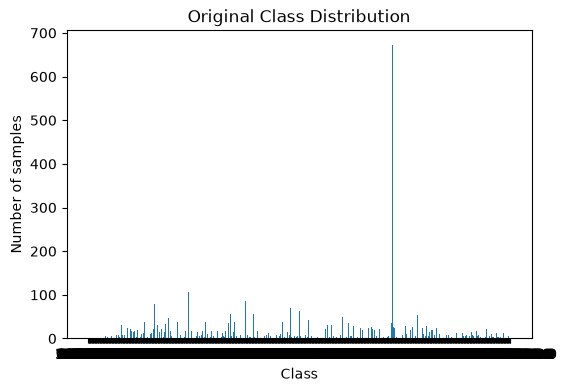

In [419]:
FEATURES_HOUSE = ['living_space', 'land_space', 'bedroom_number',
                  'bathroom_number', 'floor_level', 'furnished',
                  'city', 'state']

house, X_house, y_house = prepare(df_house, FEATURES_HOUSE)

# คอลัมน์ข้อความของ Detached House: floor_level, furnished, city, state
floor_enc_house = LabelEncoder().fit(X_house['floor_level'])
furn_enc_house = LabelEncoder().fit(X_house['furnished'])
city_enc_house = LabelEncoder().fit(X_house['city'])
state_enc_house = LabelEncoder().fit(X_house['state'])

X_house['floor_level'] = floor_enc_house.transform(X_house['floor_level'])
X_house['furnished'] = furn_enc_house.transform(X_house['furnished'])
X_house['city'] = city_enc_house.transform(X_house['city'])
X_house['state'] = state_enc_house.transform(X_house['state'])

X_train_house, X_test_house, y_train_house, y_test_house = train_test_split(
    X_house, y_house, test_size=TEST_SIZE, random_state=RANDOM_STATE)

print(f'rows={len(house)}  train={len(X_train_house)}  test={len(X_test_house)}')
print(f'price kept: 100,000 - {house["price"].quantile(PRICE_QUANTILE):,.0f}')
classDistribution = y_house.value_counts().sort_index()
plt.figure(figsize=(6, 4))
plt.bar(classDistribution.index.astype(str), classDistribution.values)
plt.xlabel("Class")
plt.ylabel("Number of samples")
plt.title("Original Class Distribution")
plt.show()

### 9.2 Detached House — DecisionTreeRegressor ค่า default

In [420]:
model_house_default = DecisionTreeRegressor(random_state=RANDOM_STATE)
model_house_default.fit(X_train_house, y_train_house)

res_house_default = report(
    model_house_default, X_test_house, y_test_house, 'DT default Detached House')

===== DT default Detached House =====
depth  = 29
leaves = 3,362
MAE  : 5,113,589.26
RMSE : 11,735,373.13
R²   : 0.4731



### 9.3 Detached House — Tune `max_depth`

In [421]:
dt_house_d3 = DecisionTreeRegressor(max_depth=3, random_state=RANDOM_STATE).fit(X_train_house, y_train_house)
dt_house_d5 = DecisionTreeRegressor(max_depth=5, random_state=RANDOM_STATE).fit(X_train_house, y_train_house)
dt_house_d8 = DecisionTreeRegressor(max_depth=8, random_state=RANDOM_STATE).fit(X_train_house, y_train_house)
dt_house_d10 = DecisionTreeRegressor(max_depth=10, random_state=RANDOM_STATE).fit(X_train_house, y_train_house)
dt_house_d12 = DecisionTreeRegressor(max_depth=12, random_state=RANDOM_STATE).fit(X_train_house, y_train_house)
dt_house_d15 = DecisionTreeRegressor(max_depth=15, random_state=RANDOM_STATE).fit(X_train_house, y_train_house)
dt_house_dnone = DecisionTreeRegressor(random_state=RANDOM_STATE).fit(X_train_house, y_train_house)

tuning_house = pd.DataFrame([
    {'max_depth': 3, **metrics(dt_house_d3, X_test_house, y_test_house)},
    {'max_depth': 5, **metrics(dt_house_d5, X_test_house, y_test_house)},
    {'max_depth': 8, **metrics(dt_house_d8, X_test_house, y_test_house)},
    {'max_depth': 10, **metrics(dt_house_d10, X_test_house, y_test_house)},
    {'max_depth': 12, **metrics(dt_house_d12, X_test_house, y_test_house)},
    {'max_depth': 15, **metrics(dt_house_d15, X_test_house, y_test_house)},
    {'max_depth': 'None', **metrics(dt_house_dnone, X_test_house, y_test_house)},
]).set_index('max_depth')

print('===== Detached House =====')
print(tuning_house.round(2).to_string())

===== Detached House =====
                  MAE         RMSE    R2
max_depth                               
3          5940910.69  11577595.63  0.49
5          5474252.70  10904795.89  0.55
8          5007521.72  10761331.96  0.56
10         5063289.39  11216509.02  0.52
12         4949487.43  11140271.11  0.53
15         5007481.89  11413194.25  0.50
None       5113589.26  11735373.13  0.47


### 9.4 Detached House — Final model (`max_depth = 8`)

ลึกเกินไปแล้ว overfit (R² ลดจาก 0.56 เป็น 0.47)

In [422]:
BEST_DEPTH_HOUSE = 8

model_house = DecisionTreeRegressor(
    max_depth=BEST_DEPTH_HOUSE, random_state=RANDOM_STATE)
model_house.fit(X_train_house, y_train_house)

res_house_tuned = report(
    model_house, X_test_house, y_test_house, 'DT tuned Detached House')

===== DT tuned Detached House =====
depth  = 8
leaves = 184
MAE  : 5,007,521.72
RMSE : 10,761,331.96
R²   : 0.5569



### 9.5 Detached House — Feature Importance

In [423]:
importance_house = pd.Series(
    model_house.feature_importances_, index=FEATURES_HOUSE
).sort_values(ascending=False)

importance_house.round(4)

living_space       0.5052
bathroom_number    0.1972
land_space         0.1206
state              0.0699
city               0.0585
floor_level        0.0214
bedroom_number     0.0148
furnished          0.0125
dtype: float64

### 9.6 Detached House — ทดลองทำนายของใหม่

In [424]:
floor_mode_house = np.bincount(floor_enc_house.transform(house['floor_level'])).argmax()
furn_mode_house = np.bincount(furn_enc_house.transform(house['furnished'])).argmax()
city_mode_house = np.bincount(city_enc_house.transform(house['city'])).argmax()
state_mode_house = np.bincount(state_enc_house.transform(house['state'])).argmax()

new_house = pd.DataFrame([
    {'living_space': 250, 'land_space': 400, 'bedroom_number': 4,
     'bathroom_number': 4, 'floor_level': '2',
     'furnished': 'Fully Furnished', 'city': 'Hua Hin',
     'state': 'Prachuap Khiri Khan'},
    {'living_space': 120, 'land_space': 200, 'bedroom_number': 3,
     'bathroom_number': 2, 'floor_level': '1',
     'furnished': 'Unfurnished', 'city': 'Bang Plee',
     'state': 'Samut Prakan'},
])

new_house['floor_level'] = encode_column(new_house['floor_level'], floor_enc_house, floor_mode_house)
new_house['furnished'] = encode_column(new_house['furnished'], furn_enc_house, furn_mode_house)
new_house['city'] = encode_column(new_house['city'], city_enc_house, city_mode_house)
new_house['state'] = encode_column(new_house['state'], state_enc_house, state_mode_house)

new_house['property_type'] = 'Detached House'
new_house['predicted_price'] = model_house.predict(new_house[FEATURES_HOUSE])

median_house = house.groupby('city')['price'].median()
new_house['median_real_price'] = new_house['city'].map(median_house)

new_house[['property_type', 'living_space', 'land_space', 'state', 'city',
           'predicted_price', 'median_real_price']].fillna('-').round(0)

,property_type,living_space,land_space,state,city,predicted_price,median_real_price
0,Detached House,250,400,28,47,10308674.0,-
1,Detached House,120,200,32,25,4179516.0,-


---

# 10) Townhouse

ชุด feature เหมือน Detached House แต่ข้อมูลน้อยกว่า (~8.5%) และราคากระจายแคบกว่า

### 10.1 Townhouse — เตรียมข้อมูลและแบ่ง train/test

In [425]:
FEATURES_TOWNHOUSE = ['living_space', 'land_space', 'bedroom_number',
                      'bathroom_number', 'floor_level', 'furnished',
                      'city', 'state']

townhouse, X_townhouse, y_townhouse = prepare(df_townhouse, FEATURES_TOWNHOUSE)

# คอลัมน์ข้อความของ Townhouse: floor_level, furnished, city, state
floor_enc_townhouse = LabelEncoder().fit(X_townhouse['floor_level'])
furn_enc_townhouse = LabelEncoder().fit(X_townhouse['furnished'])
city_enc_townhouse = LabelEncoder().fit(X_townhouse['city'])
state_enc_townhouse = LabelEncoder().fit(X_townhouse['state'])

X_townhouse['floor_level'] = floor_enc_townhouse.transform(X_townhouse['floor_level'])
X_townhouse['furnished'] = furn_enc_townhouse.transform(X_townhouse['furnished'])
X_townhouse['city'] = city_enc_townhouse.transform(X_townhouse['city'])
X_townhouse['state'] = state_enc_townhouse.transform(X_townhouse['state'])

X_train_townhouse, X_test_townhouse, y_train_townhouse, y_test_townhouse = train_test_split(
    X_townhouse, y_townhouse, test_size=TEST_SIZE, random_state=RANDOM_STATE)

print(f'rows={len(townhouse)}  train={len(X_train_townhouse)}  test={len(X_test_townhouse)}')
print(f'price kept: 100,000 - {townhouse["price"].quantile(PRICE_QUANTILE):,.0f}')

rows=3539  train=2477  test=1062
price kept: 100,000 - 25,000,000


### 10.2 Townhouse — DecisionTreeRegressor ค่า default

In [426]:
model_townhouse_default = DecisionTreeRegressor(random_state=RANDOM_STATE)
model_townhouse_default.fit(X_train_townhouse, y_train_townhouse)

res_townhouse_default = report(
    model_townhouse_default, X_test_townhouse, y_test_townhouse,
    'DT default Townhouse')

===== DT default Townhouse =====
depth  = 28
leaves = 2,240
MAE  : 1,405,943.42
RMSE : 2,809,135.55
R²   : 0.6240



### 10.3 Townhouse — Tune `max_depth`

In [427]:
dt_townhouse_d3 = DecisionTreeRegressor(max_depth=3, random_state=RANDOM_STATE).fit(X_train_townhouse, y_train_townhouse)
dt_townhouse_d5 = DecisionTreeRegressor(max_depth=5, random_state=RANDOM_STATE).fit(X_train_townhouse, y_train_townhouse)
dt_townhouse_d8 = DecisionTreeRegressor(max_depth=8, random_state=RANDOM_STATE).fit(X_train_townhouse, y_train_townhouse)
dt_townhouse_d10 = DecisionTreeRegressor(max_depth=10, random_state=RANDOM_STATE).fit(X_train_townhouse, y_train_townhouse)
dt_townhouse_d12 = DecisionTreeRegressor(max_depth=12, random_state=RANDOM_STATE).fit(X_train_townhouse, y_train_townhouse)
dt_townhouse_d15 = DecisionTreeRegressor(max_depth=15, random_state=RANDOM_STATE).fit(X_train_townhouse, y_train_townhouse)
dt_townhouse_dnone = DecisionTreeRegressor(random_state=RANDOM_STATE).fit(X_train_townhouse, y_train_townhouse)

tuning_townhouse = pd.DataFrame([
    {'max_depth': 3, **metrics(dt_townhouse_d3, X_test_townhouse, y_test_townhouse)},
    {'max_depth': 5, **metrics(dt_townhouse_d5, X_test_townhouse, y_test_townhouse)},
    {'max_depth': 8, **metrics(dt_townhouse_d8, X_test_townhouse, y_test_townhouse)},
    {'max_depth': 10, **metrics(dt_townhouse_d10, X_test_townhouse, y_test_townhouse)},
    {'max_depth': 12, **metrics(dt_townhouse_d12, X_test_townhouse, y_test_townhouse)},
    {'max_depth': 15, **metrics(dt_townhouse_d15, X_test_townhouse, y_test_townhouse)},
    {'max_depth': 'None', **metrics(dt_townhouse_dnone, X_test_townhouse, y_test_townhouse)},
]).set_index('max_depth')

print('===== Townhouse =====')
print(tuning_townhouse.round(2).to_string())

===== Townhouse =====
                  MAE        RMSE    R2
max_depth                              
3          1666251.26  2781516.82  0.63
5          1534279.49  2635535.48  0.67
8          1381548.85  2532026.14  0.69
10         1369136.42  2636283.87  0.67
12         1363254.85  2694434.43  0.65
15         1381580.90  2722525.69  0.65
None       1405943.42  2809135.55  0.62


### 10.4 Townhouse — Final model (`max_depth = 8`)

In [428]:
BEST_DEPTH_TOWNHOUSE = 8

model_townhouse = DecisionTreeRegressor(
    max_depth=BEST_DEPTH_TOWNHOUSE, random_state=RANDOM_STATE)
model_townhouse.fit(X_train_townhouse, y_train_townhouse)

res_townhouse_tuned = report(
    model_townhouse, X_test_townhouse, y_test_townhouse, 'DT tuned Townhouse')

===== DT tuned Townhouse =====
depth  = 8
leaves = 141
MAE  : 1,381,548.85
RMSE : 2,532,026.14
R²   : 0.6945



### 10.5 Townhouse — Feature Importance

In [429]:
importance_townhouse = pd.Series(
    model_townhouse.feature_importances_, index=FEATURES_TOWNHOUSE
).sort_values(ascending=False)

importance_townhouse.round(4)

living_space       0.4604
floor_level        0.1928
city               0.1743
land_space         0.0998
bathroom_number    0.0294
state              0.0237
bedroom_number     0.0115
furnished          0.0081
dtype: float64

### 10.6 Townhouse — ทดลองทำนายของใหม่

In [430]:
floor_mode_townhouse = np.bincount(floor_enc_townhouse.transform(townhouse['floor_level'])).argmax()
furn_mode_townhouse = np.bincount(furn_enc_townhouse.transform(townhouse['furnished'])).argmax()
city_mode_townhouse = np.bincount(city_enc_townhouse.transform(townhouse['city'])).argmax()
state_mode_townhouse = np.bincount(state_enc_townhouse.transform(townhouse['state'])).argmax()

new_townhouse = pd.DataFrame([
    {'living_space': 180, 'land_space': 200, 'bedroom_number': 3,
     'bathroom_number': 3, 'floor_level': '2',
     'furnished': 'Partially Furnished', 'city': 'Bang Plee',
     'state': 'Samut Prakan'},
])

new_townhouse['floor_level'] = encode_column(new_townhouse['floor_level'], floor_enc_townhouse, floor_mode_townhouse)
new_townhouse['furnished'] = encode_column(new_townhouse['furnished'], furn_enc_townhouse, furn_mode_townhouse)
new_townhouse['city'] = encode_column(new_townhouse['city'], city_enc_townhouse, city_mode_townhouse)
new_townhouse['state'] = encode_column(new_townhouse['state'], state_enc_townhouse, state_mode_townhouse)

new_townhouse['property_type'] = 'Townhouse'
new_townhouse['predicted_price'] = model_townhouse.predict(new_townhouse[FEATURES_TOWNHOUSE])

median_townhouse = townhouse.groupby('city')['price'].median()
new_townhouse['median_real_price'] = new_townhouse['city'].map(median_townhouse)

new_townhouse[['property_type', 'living_space', 'land_space', 'state', 'city',
               'predicted_price', 'median_real_price']].fillna('-').round(0)

,property_type,living_space,land_space,state,city,predicted_price,median_real_price
0,Townhouse,180,200,23,17,3257231.0,-


---

# 11) Apartment

ข้อมูลน้อยที่สุด (~2%) และไม่มี `bedroom_number` / `bathroom_number` ที่ครบ (coverage < 5%) จึงใช้แค่ 6 คอลัมน์

### 11.1 Apartment — เตรียมข้อมูลและแบ่ง train/test

rows=1551  train=1085  test=466
price kept: 100,000 - 219,900,000


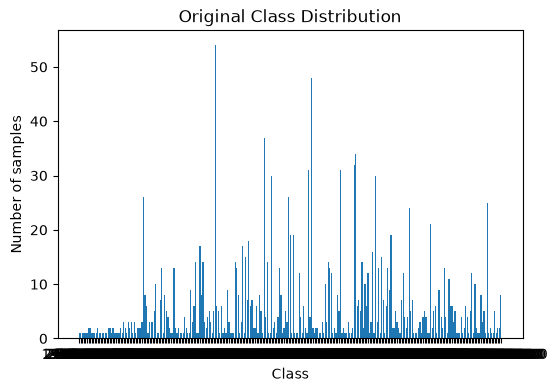

In [431]:
FEATURES_APARTMENT = ['living_space', 'land_space', 'floor_level',
                      'furnished', 'city', 'state']

apartment, X_apartment, y_apartment = prepare(df_apartment, FEATURES_APARTMENT)

# คอลัมน์ข้อความของ Apartment: floor_level, furnished, city, state
floor_enc_apartment = LabelEncoder().fit(X_apartment['floor_level'])
furn_enc_apartment = LabelEncoder().fit(X_apartment['furnished'])
city_enc_apartment = LabelEncoder().fit(X_apartment['city'])
state_enc_apartment = LabelEncoder().fit(X_apartment['state'])

X_apartment['floor_level'] = floor_enc_apartment.transform(X_apartment['floor_level'])
X_apartment['furnished'] = furn_enc_apartment.transform(X_apartment['furnished'])
X_apartment['city'] = city_enc_apartment.transform(X_apartment['city'])
X_apartment['state'] = state_enc_apartment.transform(X_apartment['state'])

X_train_apartment, X_test_apartment, y_train_apartment, y_test_apartment = train_test_split(
    X_apartment, y_apartment, test_size=TEST_SIZE, random_state=RANDOM_STATE)

print(f'rows={len(apartment)}  train={len(X_train_apartment)}  test={len(X_test_apartment)}')
print(f'price kept: 100,000 - {apartment["price"].quantile(PRICE_QUANTILE):,.0f}')

classDistribution = y_apartment.value_counts().sort_index()
plt.figure(figsize=(6, 4))
plt.bar(classDistribution.index.astype(str), classDistribution.values)
plt.xlabel("Class")
plt.ylabel("Number of samples")
plt.title("Original Class Distribution")
plt.show()

### 11.2 Apartment — DecisionTreeRegressor ค่า default

In [432]:
model_apartment_default = DecisionTreeRegressor(random_state=RANDOM_STATE)
model_apartment_default.fit(X_train_apartment, y_train_apartment)

res_apartment_default = report(
    model_apartment_default, X_test_apartment, y_test_apartment,
    'DT default Apartment')

===== DT default Apartment =====
depth  = 23
leaves = 563
MAE  : 7,165,880.99
RMSE : 20,691,632.46
R²   : 0.7748



### 11.3 Apartment — Tune `max_depth`

In [433]:
dt_apartment_d3 = DecisionTreeRegressor(max_depth=3, random_state=RANDOM_STATE).fit(X_train_apartment, y_train_apartment)
dt_apartment_d5 = DecisionTreeRegressor(max_depth=5, random_state=RANDOM_STATE).fit(X_train_apartment, y_train_apartment)
dt_apartment_d8 = DecisionTreeRegressor(max_depth=8, random_state=RANDOM_STATE).fit(X_train_apartment, y_train_apartment)
dt_apartment_d10 = DecisionTreeRegressor(max_depth=10, random_state=RANDOM_STATE).fit(X_train_apartment, y_train_apartment)
dt_apartment_d12 = DecisionTreeRegressor(max_depth=12, random_state=RANDOM_STATE).fit(X_train_apartment, y_train_apartment)
dt_apartment_d15 = DecisionTreeRegressor(max_depth=15, random_state=RANDOM_STATE).fit(X_train_apartment, y_train_apartment)
dt_apartment_dnone = DecisionTreeRegressor(random_state=RANDOM_STATE).fit(X_train_apartment, y_train_apartment)

tuning_apartment = pd.DataFrame([
    {'max_depth': 3, **metrics(dt_apartment_d3, X_test_apartment, y_test_apartment)},
    {'max_depth': 5, **metrics(dt_apartment_d5, X_test_apartment, y_test_apartment)},
    {'max_depth': 8, **metrics(dt_apartment_d8, X_test_apartment, y_test_apartment)},
    {'max_depth': 10, **metrics(dt_apartment_d10, X_test_apartment, y_test_apartment)},
    {'max_depth': 12, **metrics(dt_apartment_d12, X_test_apartment, y_test_apartment)},
    {'max_depth': 15, **metrics(dt_apartment_d15, X_test_apartment, y_test_apartment)},
    {'max_depth': 'None', **metrics(dt_apartment_dnone, X_test_apartment, y_test_apartment)},
]).set_index('max_depth')

print('===== Apartment =====')
print(tuning_apartment.round(2).to_string())

===== Apartment =====
                   MAE         RMSE    R2
max_depth                                
3          17972043.00  27213771.34  0.61
5          13753516.79  23766815.58  0.70
8          10931416.16  21860265.45  0.75
10          8735492.09  19453523.27  0.80
12          7334839.01  20135338.64  0.79
15          7901836.71  21581203.35  0.76
None        7165880.99  20691632.46  0.77


### 11.4 Apartment — Final model (`max_depth = 10`)

ข้อมูลน้อย ต้นไม้ลึกเกินจะทำนายคลาดเคลื่อน

In [434]:
BEST_DEPTH_APARTMENT = 10

model_apartment = DecisionTreeRegressor(
    max_depth=BEST_DEPTH_APARTMENT, random_state=RANDOM_STATE)
model_apartment.fit(X_train_apartment, y_train_apartment)

res_apartment_tuned = report(
    model_apartment, X_test_apartment, y_test_apartment, 'DT tuned Apartment')

===== DT tuned Apartment =====
depth  = 10
leaves = 279
MAE  : 8,735,492.09
RMSE : 19,453,523.27
R²   : 0.8009



### 11.5 Apartment — Feature Importance

In [435]:
importance_apartment = pd.Series(
    model_apartment.feature_importances_, index=FEATURES_APARTMENT
).sort_values(ascending=False)

importance_apartment.round(4)

living_space    0.4371
land_space      0.2869
floor_level     0.1832
city            0.0800
state           0.0083
furnished       0.0045
dtype: float64

### 11.6 Apartment — ทดลองทำนายของใหม่

In [436]:
floor_mode_apartment = np.bincount(floor_enc_apartment.transform(apartment['floor_level'])).argmax()
furn_mode_apartment = np.bincount(furn_enc_apartment.transform(apartment['furnished'])).argmax()
city_mode_apartment = np.bincount(city_enc_apartment.transform(apartment['city'])).argmax()
state_mode_apartment = np.bincount(state_enc_apartment.transform(apartment['state'])).argmax()

new_apartment = pd.DataFrame([
    {'living_space': 90, 'land_space': 120, 'floor_level': '8',
     'furnished': 'Fully Furnished', 'city': 'Chatuchak',
     'state': 'Bangkok'},
])

new_apartment['floor_level'] = encode_column(new_apartment['floor_level'], floor_enc_apartment, floor_mode_apartment)
new_apartment['furnished'] = encode_column(new_apartment['furnished'], furn_enc_apartment, furn_mode_apartment)
new_apartment['city'] = encode_column(new_apartment['city'], city_enc_apartment, city_mode_apartment)
new_apartment['state'] = encode_column(new_apartment['state'], state_enc_apartment, state_mode_apartment)

new_apartment['property_type'] = 'Apartment'
new_apartment['predicted_price'] = model_apartment.predict(new_apartment[FEATURES_APARTMENT])

median_apartment = apartment.groupby('city')['price'].median()
new_apartment['median_real_price'] = new_apartment['city'].map(median_apartment)

new_apartment[['property_type', 'living_space', 'land_space', 'state', 'city',
               'predicted_price', 'median_real_price']].fillna('-').round(0)

,property_type,living_space,land_space,state,city,predicted_price,median_real_price
0,Apartment,90,120,0,20,24000000.0,-


---

# 12) Land

ที่ดินเปล่า ๆ มีแค่ 3 คอลัมน์ที่ใช้ได้ (`land_space`, `city`, `state`) เพราะ `living_space` = **0%**

### 12.1 Land — เตรียมข้อมูลและแบ่ง train/test

rows=24886  train=17420  test=7466
price kept: 100,000 - 765,000,000


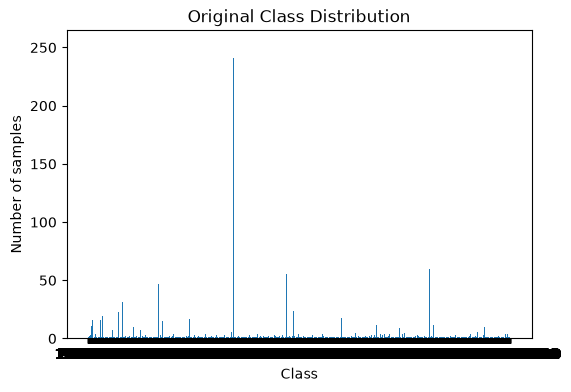

In [437]:
FEATURES_LAND = ['land_space', 'city', 'state']

land, X_land, y_land = prepare(df_land, FEATURES_LAND)

# คอลัมน์ข้อความของ Land: city, state
city_enc_land = LabelEncoder().fit(X_land['city'])
state_enc_land = LabelEncoder().fit(X_land['state'])

X_land['city'] = city_enc_land.transform(X_land['city'])
X_land['state'] = state_enc_land.transform(X_land['state'])

X_train_land, X_test_land, y_train_land, y_test_land = train_test_split(
    X_land, y_land, test_size=TEST_SIZE, random_state=RANDOM_STATE)

print(f'rows={len(land)}  train={len(X_train_land)}  test={len(X_test_land)}')
print(f'price kept: 100,000 - {land["price"].quantile(PRICE_QUANTILE):,.0f}')

classDistribution = y_land.value_counts().sort_index()
plt.figure(figsize=(6, 4))
plt.bar(classDistribution.index.astype(str), classDistribution.values)
plt.xlabel("Class")
plt.ylabel("Number of samples")
plt.title("Original Class Distribution")
plt.show()

### 12.2 Land — DecisionTreeRegressor ค่า default

In [438]:
model_land_default = DecisionTreeRegressor(random_state=RANDOM_STATE)
model_land_default.fit(X_train_land, y_train_land)

res_land_default = report(
    model_land_default, X_test_land, y_test_land, 'DT default Land')

===== DT default Land =====
depth  = 32
leaves = 12,817
MAE  : 47,349,077.44
RMSE : 131,247,018.07
R²   : 0.1804



### 12.3 Land — Tune `max_depth`

In [439]:
dt_land_d3 = DecisionTreeRegressor(max_depth=3, random_state=RANDOM_STATE).fit(X_train_land, y_train_land)
dt_land_d5 = DecisionTreeRegressor(max_depth=5, random_state=RANDOM_STATE).fit(X_train_land, y_train_land)
dt_land_d8 = DecisionTreeRegressor(max_depth=8, random_state=RANDOM_STATE).fit(X_train_land, y_train_land)
dt_land_d10 = DecisionTreeRegressor(max_depth=10, random_state=RANDOM_STATE).fit(X_train_land, y_train_land)
dt_land_d12 = DecisionTreeRegressor(max_depth=12, random_state=RANDOM_STATE).fit(X_train_land, y_train_land)
dt_land_d15 = DecisionTreeRegressor(max_depth=15, random_state=RANDOM_STATE).fit(X_train_land, y_train_land)
dt_land_dnone = DecisionTreeRegressor(random_state=RANDOM_STATE).fit(X_train_land, y_train_land)

tuning_land = pd.DataFrame([
    {'max_depth': 3, **metrics(dt_land_d3, X_test_land, y_test_land)},
    {'max_depth': 5, **metrics(dt_land_d5, X_test_land, y_test_land)},
    {'max_depth': 8, **metrics(dt_land_d8, X_test_land, y_test_land)},
    {'max_depth': 10, **metrics(dt_land_d10, X_test_land, y_test_land)},
    {'max_depth': 12, **metrics(dt_land_d12, X_test_land, y_test_land)},
    {'max_depth': 15, **metrics(dt_land_d15, X_test_land, y_test_land)},
    {'max_depth': 'None', **metrics(dt_land_dnone, X_test_land, y_test_land)},
]).set_index('max_depth')

print('===== Land =====')
print(tuning_land.round(2).to_string())

===== Land =====
                   MAE          RMSE    R2
max_depth                                 
3          65210643.45  1.291735e+08  0.21
5          59092231.27  1.227537e+08  0.28
8          54583452.16  1.207813e+08  0.31
10         52213787.75  1.223999e+08  0.29
12         51203815.73  1.257527e+08  0.25
15         49060751.75  1.269162e+08  0.23
None       47349077.44  1.312470e+08  0.18


### 12.4 Land — Final model (`max_depth = 8`)

MAE ต่ำสุดอยู่ที่ depth 15 แต่ R² สูงสุดที่ 8 (default ได้แค่ 0.18)

In [440]:
BEST_DEPTH_LAND = 8

model_land = DecisionTreeRegressor(
    max_depth=BEST_DEPTH_LAND, random_state=RANDOM_STATE)
model_land.fit(X_train_land, y_train_land)

res_land_tuned = report(
    model_land, X_test_land, y_test_land, 'DT tuned Land')

===== DT tuned Land =====
depth  = 8
leaves = 208
MAE  : 54,583,452.16
RMSE : 120,781,252.49
R²   : 0.3059



### 12.5 Land — Feature Importance

In [441]:
importance_land = pd.Series(
    model_land.feature_importances_, index=FEATURES_LAND
).sort_values(ascending=False)

importance_land.round(4)

land_space    0.5072
state         0.2864
city          0.2064
dtype: float64

### 12.6 Land — ทดลองทำนายของใหม่

In [442]:
city_mode_land = np.bincount(city_enc_land.transform(land['city'])).argmax()
state_mode_land = np.bincount(state_enc_land.transform(land['state'])).argmax()

new_land = pd.DataFrame([
    {'land_space': 500, 'city': 'Bang Plee', 'state': 'Bangkok'},
    {'land_space': 1000, 'city': 'Chatuchak', 'state': 'Bangkok'},
    {'land_space': 1500, 'city': 'Dusit', 'state': 'Bangkok'},
])

new_land['city'] = encode_column(new_land['city'], city_enc_land, city_mode_land)
new_land['state'] = encode_column(new_land['state'], state_enc_land, state_mode_land)

new_land['property_type'] = 'Land'
new_land['predicted_price'] = model_land.predict(new_land[FEATURES_LAND])

median_land = land.groupby('city')['price'].median()
new_land['median_real_price'] = new_land['city'].map(median_land)

new_land[['property_type', 'land_space', 'state', 'city',
          'predicted_price', 'median_real_price']].fillna('-').round(0)

,property_type,land_space,state,city,predicted_price,median_real_price
0,Land,500,2,59,18776845.0,-
1,Land,1000,2,97,50546649.0,-
2,Land,1500,2,133,50546649.0,-


---

# 13) รวมผลของทั้ง 5 กลุ่ม

ตอนนี้ทุกกลุ่มอยู่ในตัวแปรของตัวเองหมดแล้ว (`res_*`, `importance_*`, `new_*`) จึงเอามาวางเทียบกันได้โดยไม่ต้อง train ซ้ำ

### 13.1 จำนวนข้อมูลของแต่ละกลุ่ม

In [443]:
data_summary = pd.DataFrame([
    {'property_type': 'Condo', 'features': len(FEATURES_CONDO),
     'rows_used': len(condo), 'train': len(X_train_condo), 'test': len(X_test_condo),
     'price_max': condo['price'].quantile(PRICE_QUANTILE)},
    {'property_type': 'Detached House', 'features': len(FEATURES_HOUSE),
     'rows_used': len(house), 'train': len(X_train_house), 'test': len(X_test_house),
     'price_max': house['price'].quantile(PRICE_QUANTILE)},
    {'property_type': 'Townhouse', 'features': len(FEATURES_TOWNHOUSE),
     'rows_used': len(townhouse), 'train': len(X_train_townhouse), 'test': len(X_test_townhouse),
     'price_max': townhouse['price'].quantile(PRICE_QUANTILE)},
    {'property_type': 'Apartment', 'features': len(FEATURES_APARTMENT),
     'rows_used': len(apartment), 'train': len(X_train_apartment), 'test': len(X_test_apartment),
     'price_max': apartment['price'].quantile(PRICE_QUANTILE)},
    {'property_type': 'Land', 'features': len(FEATURES_LAND),
     'rows_used': len(land), 'train': len(X_train_land), 'test': len(X_test_land),
     'price_max': land['price'].quantile(PRICE_QUANTILE)},
]).set_index('property_type')

data_summary.round(0)

,features,rows_used,train,test,price_max
property_type,,,,,
Condo,8,39020,27314,11706,33000000.0
Detached House,8,6033,4223,1810,85000000.0
Townhouse,8,3539,2477,1062,25000000.0
Apartment,6,1551,1085,466,219900000.0
Land,3,24886,17420,7466,765000000.0


### 13.2 เปรียบเทียบ default กับ tuned

In [444]:
comparison = pd.DataFrame([
    {'Method': 'DT default Condo', 'max_depth': 'None', **res_condo_default},
    {'Method': 'DT tuned Condo', 'max_depth': BEST_DEPTH_CONDO, **res_condo_tuned},
    {'Method': 'DT default Detached House', 'max_depth': 'None', **res_house_default},
    {'Method': 'DT tuned Detached House', 'max_depth': BEST_DEPTH_HOUSE, **res_house_tuned},
    {'Method': 'DT default Townhouse', 'max_depth': 'None', **res_townhouse_default},
    {'Method': 'DT tuned Townhouse', 'max_depth': BEST_DEPTH_TOWNHOUSE, **res_townhouse_tuned},
    {'Method': 'DT default Apartment', 'max_depth': 'None', **res_apartment_default},
    {'Method': 'DT tuned Apartment', 'max_depth': BEST_DEPTH_APARTMENT, **res_apartment_tuned},
    {'Method': 'DT default Land', 'max_depth': 'None', **res_land_default},
    {'Method': 'DT tuned Land', 'max_depth': BEST_DEPTH_LAND, **res_land_tuned},
]).set_index('Method')

comparison.round(2)

,max_depth,MAE,RMSE,R2
Method,,,,
DT default Condo,None,857173.53,2.142260e+06,0.87
DT tuned Condo,15,948466.80,2.134123e+06,0.87
DT default Detached House,None,5113589.26,1.173537e+07,0.47
DT tuned Detached House,8,5007521.72,1.076133e+07,0.56
DT default Townhouse,None,1405943.42,2.809136e+06,0.62
DT tuned Townhouse,8,1381548.85,2.532026e+06,0.69
DT default Apartment,None,7165880.99,2.069163e+07,0.77
DT tuned Apartment,10,8735492.09,1.945352e+07,0.80
DT default Land,None,47349077.44,1.312470e+08,0.18


การจำกัด `max_depth` ช่วยมากที่สุดกับ **Land (+0.13)** รองลงมาคือ **Detached House (+0.08)**, **Townhouse (+0.07)** และ **Apartment (+0.03)**

ส่วน Condo แทบไม่เปลี่ยน เพราะข้อมูลเยอะพอที่ default จะยังไม่ overfit รุนแรง

### 13.3 เทียบค่า `max_depth` ที่ดีที่สุดของแต่ละกลุ่ม

In [445]:
best_depth_summary = pd.DataFrame([
    {'property_type': 'Condo', 'best_max_depth': BEST_DEPTH_CONDO, 'R2': res_condo_tuned['R2']},
    {'property_type': 'Detached House', 'best_max_depth': BEST_DEPTH_HOUSE, 'R2': res_house_tuned['R2']},
    {'property_type': 'Townhouse', 'best_max_depth': BEST_DEPTH_TOWNHOUSE, 'R2': res_townhouse_tuned['R2']},
    {'property_type': 'Apartment', 'best_max_depth': BEST_DEPTH_APARTMENT, 'R2': res_apartment_tuned['R2']},
    {'property_type': 'Land', 'best_max_depth': BEST_DEPTH_LAND, 'R2': res_land_tuned['R2']},
]).set_index('property_type')

best_depth_summary.round(4)

,best_max_depth,R2
property_type,,
Condo,15,0.8722
Detached House,8,0.5569
Townhouse,8,0.6945
Apartment,10,0.8009
Land,8,0.3059


### 13.4 Feature Importance ของทั้ง 5 กลุ่ม

In [446]:
importance_all = pd.DataFrame({
    'Condo': importance_condo,
    'Detached House': importance_house,
    'Townhouse': importance_townhouse,
    'Apartment': importance_apartment,
    'Land': importance_land,
}).fillna(0)

importance_all.round(4)

,Condo,Detached House,Townhouse,Apartment,Land
bathroom_number,0.0188,0.1972,0.0294,0.0000,0.0000
bedroom_number,0.0163,0.0148,0.0115,0.0000,0.0000
built_year,0.0983,0.0000,0.0000,0.0000,0.0000
city,0.1048,0.0585,0.1743,0.0800,0.2064
floor_level,0.0341,0.0214,0.1928,0.1832,0.0000
furnished,0.0000,0.0125,0.0081,0.0045,0.0000
land_space,0.0000,0.1206,0.0998,0.2869,0.5072
living_space,0.7119,0.5052,0.4604,0.4371,0.0000
state,0.0155,0.0699,0.0237,0.0083,0.2864
tenure,0.0004,0.0000,0.0000,0.0000,0.0000


**`living_space` สำคัญที่สุดทุกกลุ่มที่มีพื้นที่ใช้สอย** (0.44 – 0.71)

ของที่ต่างกัน:
- Condo: `built_year` (0.10) สำคัญ — คอนโดใหม่ราคาแพงกว่า
- Detached House: `bathroom_number` (0.20) — บ้านใหญ่ต้องมีห้องน้ำเยอะ
- Townhouse: `floor_level` (0.19) — ตู้สองชั้นราคาต่างกันมาก
- Apartment: `land_space` (0.29) — อพาร์ตเมนต์ขายเป็นตารางเมตรคล้ายที่ดิน
- Land: `land_space` (0.51) > `state` (0.29) > `city` (0.21) — ที่ดินไม่มี `living_space` เลย ราคาจึงขึ้นกับขนาดที่ดินเป็นอันดับแรก

### 13.5 กราฟเทียบค่า R² ของแต่ละกลุ่ม

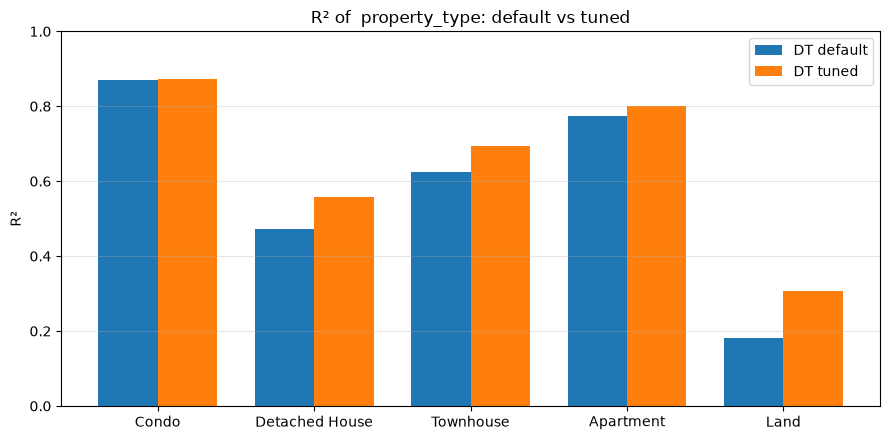

In [447]:
r2_default = [res_condo_default['R2'], res_house_default['R2'],
              res_townhouse_default['R2'], res_apartment_default['R2'],
              res_land_default['R2']]

r2_tuned = [res_condo_tuned['R2'], res_house_tuned['R2'],
            res_townhouse_tuned['R2'], res_apartment_tuned['R2'],
            res_land_tuned['R2']]

group_names = ['Condo', 'Detached House', 'Townhouse', 'Apartment', 'Land']
positions = np.arange(len(group_names))
width = 0.38

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(positions - width / 2, r2_default, width, label='DT default')
ax.bar(positions + width / 2, r2_tuned, width, label='DT tuned')
ax.set_xticks(positions)
ax.set_xticklabels(group_names)
ax.set_ylabel('R²')
ax.set_ylim(0, 1)
ax.set_title('R² of  property_type: default vs tuned')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### 13.6 ตารางราคาที่ทำนายของใหม่ (ทุกกลุ่มรวมกัน)

In [448]:
def sel(df, cols):
    return df.reindex(columns=cols, fill_value='-')

result = pd.concat(
    [
        sel(new_condo, ['property_type', 'living_space', 'land_space', 'state', 'city', 'predicted_price', 'median_real_price']),
        sel(new_house, ['property_type', 'living_space', 'land_space', 'state', 'city', 'predicted_price', 'median_real_price']),
        sel(new_townhouse, ['property_type', 'living_space', 'land_space', 'state', 'city', 'predicted_price', 'median_real_price']),
        sel(new_apartment, ['property_type', 'living_space', 'land_space', 'state', 'city', 'predicted_price', 'median_real_price']),
        sel(new_land, ['property_type', 'living_space', 'land_space', 'state', 'city', 'predicted_price', 'median_real_price']),
    ],
)

result.round(0)

,property_type,living_space,land_space,state,city,predicted_price,median_real_price
0,Condo,35,-,0,78,8034643.0,NaN
1,Condo,120,-,0,16,20260000.0,NaN
0,Detached House,250,400,28,47,10308674.0,NaN
1,Detached House,120,200,32,25,4179516.0,NaN
0,Townhouse,180,200,23,17,3257231.0,NaN
0,Apartment,90,120,0,20,24000000.0,NaN
0,Land,-,500,2,59,18776845.0,NaN
1,Land,-,1000,2,97,50546649.0,NaN
2,Land,-,1500,2,133,50546649.0,NaN


### 13.7 สรุป

### ผลลัพธ์

| กลุ่ม | max_depth | MAE | RMSE | R² |
|---|---|---|---|---|
| Condo | 15 | 948,467 | 2,134,123 | **0.8722** |
| Detached House | 8 | 5,007,522 | 10,761,332 | 0.5569 |
| Townhouse | 8 | 1,381,549 | 2,532,026 | 0.6945 |
| Apartment | 10 | 8,735,492 | 19,453,523 | **0.8009** |
| Land | 8 | 54,583,452 | 120,781,252 | 0.3059 |
